In [2]:
#Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
#Read dataset
data = pd.read_csv('data_cardiovascular_risk.csv')
#Display top 5 rows
data.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [4]:
#Check shape
data.shape

(3390, 17)

In [5]:
#Check dataypes of features
data.dtypes

id                   int64
age                  int64
education          float64
sex                 object
is_smoking          object
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [6]:
#Check for null values in the features
data.isnull().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

In [7]:
#Check statistics
data.describe()

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.000000,3390.000000,3303.000000,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
mean,1694.500000,49.542183,1.970936,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,978.753033,8.592878,1.019081,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,847.250000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,1694.500000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,2541.750000,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000
max,3389.000000,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.00000,142.500000,56.800000,143.000000,394.000000,1.000000


# Exploratory Data Analysis (EDA)

In [8]:
#drop id column
data.drop('id',axis=1,inplace=True)

<Axes: >

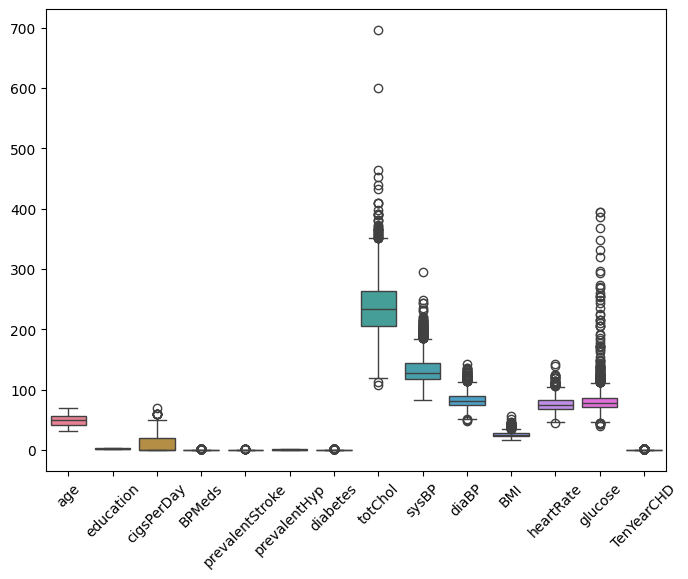

In [9]:
#Boxplot
plt.figure(figsize=(8,6))
plt.xticks(rotation = 45)
sns.boxplot(data)

<Axes: xlabel='age', ylabel='Count'>

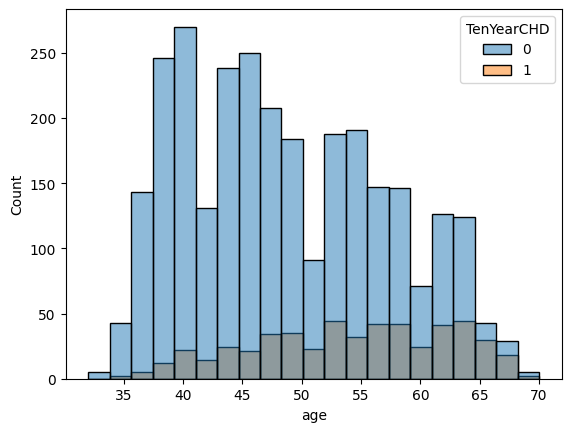

In [11]:
#does age affect chances of developing a heart disease
sns.histplot(x = 'age',hue = 'TenYearCHD',data = data)

In [13]:
data['age'].min(),data['age'].max(), data['age'].mean()

(np.int64(32), np.int64(70), np.float64(49.54218289085546))

In [14]:
#creating age categories using binning 
def age_category(x):
    
    if x > 30 and x <=45:
        return 'Adult'
    elif x > 45 and x <= 60:
        return 'Middle-Aged'
    else:
        return 'Old'
data['age_category'] = data['age'].apply(age_category)

<Axes: xlabel='age_category', ylabel='count'>

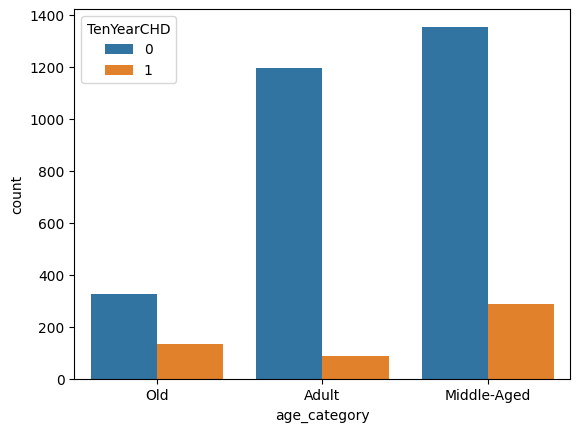

In [15]:
#TenYearCHD as compared to age buckets
sns.countplot(x = 'age_category',hue='TenYearCHD',data = data)

In [171]:
#Unique values in education column
data['education'].unique()

array([ 2.,  4.,  1.,  3., nan])

In [172]:
#Replace null values in education column with mode
data['education'] = np.where(data['education'].isnull(),data['education'].mode(),data['education'])

In [173]:
#Replace null values in cigsperday, totChol, BMI, heartRate, glucose column with median
data['cigsPerDay'] = np.where(data['cigsPerDay'].isnull(),data['cigsPerDay'].median(),data['cigsPerDay'])
data['totChol'] = np.where(data['totChol'].isnull(),data['totChol'].median(),data['totChol'])
data['BMI'] = np.where(data['BMI'].isnull(),data['BMI'].median(),data['BMI'])
data['heartRate'] = np.where(data['heartRate'].isnull(),data['heartRate'].median(),data['heartRate'])
data['glucose'] = np.where(data['glucose'].isnull(),data['glucose'].median(),data['glucose'])

In [174]:
#Replace null values in BPMeds column with mode
data['BPMeds'] = np.where(data['BPMeds'].isnull(),data['BPMeds'].mode(),data['BPMeds'])

In [175]:
#Convert sex and is_smoking columns to binary encoded labels
data['sex'] = np.where(data['sex']=='M',1,0)
data['is_smoking'] = np.where(data['is_smoking']=='YES',1,0)

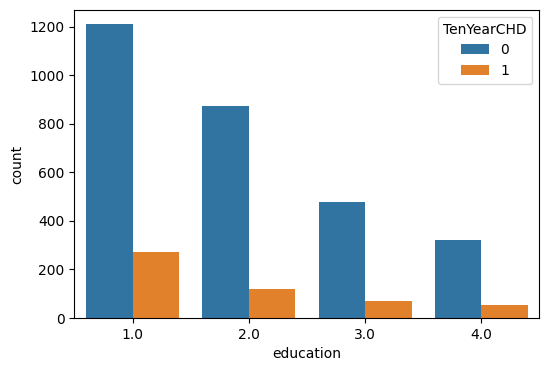

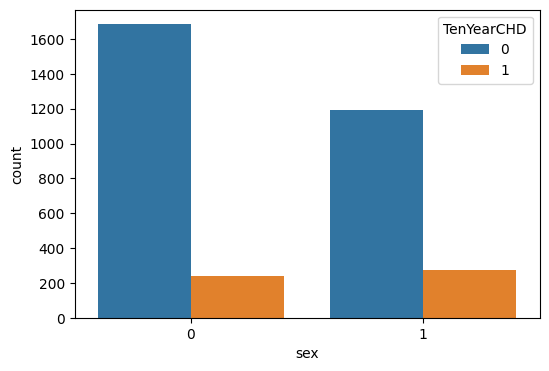

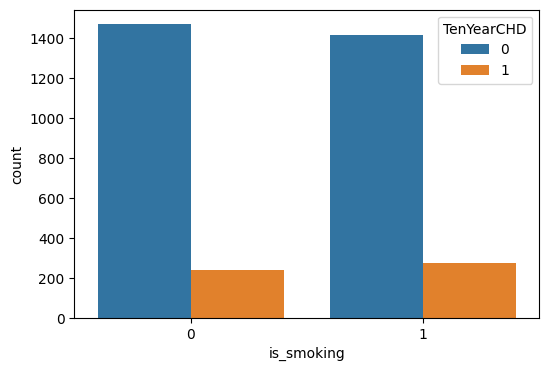

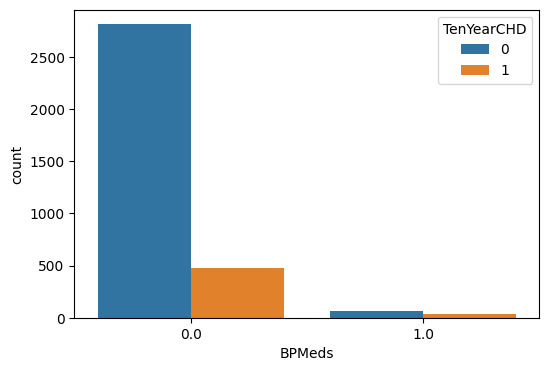

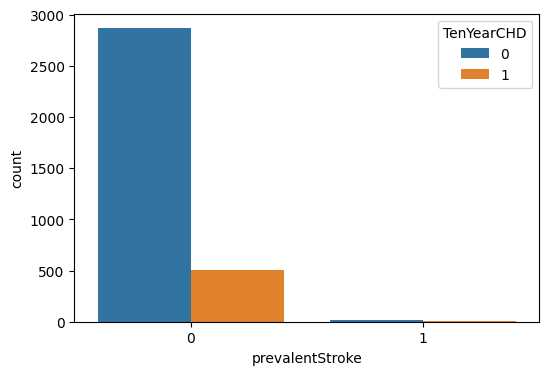

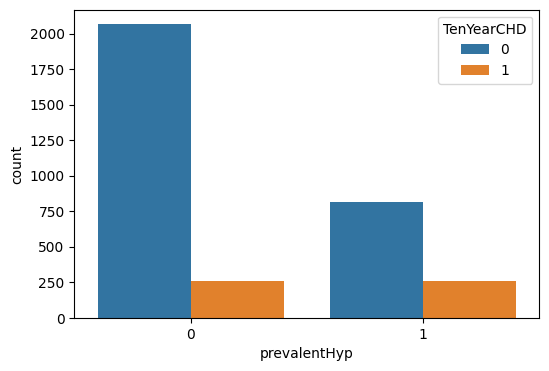

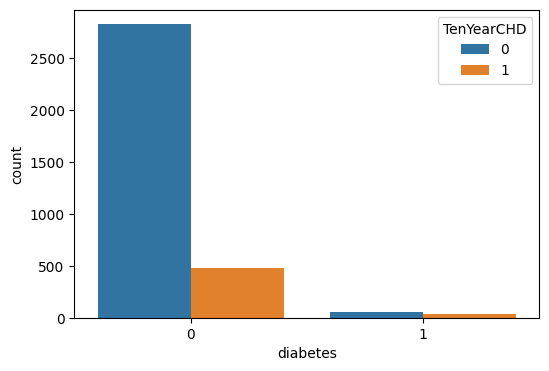

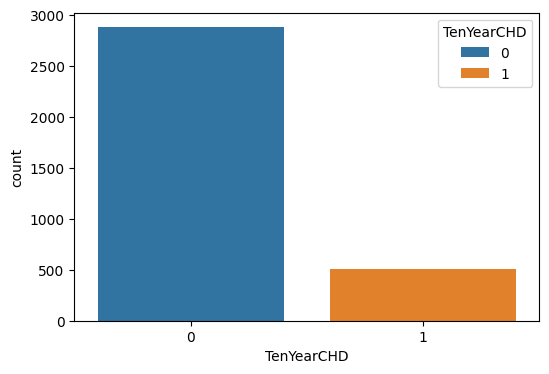

In [176]:
#analyze relationship between categorical variables and heart disease
categorical_df = data.loc[:,['education','sex','is_smoking','BPMeds','prevalentStroke','prevalentHyp','diabetes','TenYearCHD']]

for i in categorical_df:
    plt.figure(figsize=(6,4))
    sns.countplot(x = i, hue = 'TenYearCHD',data = categorical_df)
    plt.show()

In [177]:
#Check for class imbalance in target variable
print(f"People with heart disease: {data['TenYearCHD'].value_counts()[1]}")
print(f"People without heart disease: {data['TenYearCHD'].value_counts()[0]}")

People with heart disease: 511
People without heart disease: 2879


<Axes: >

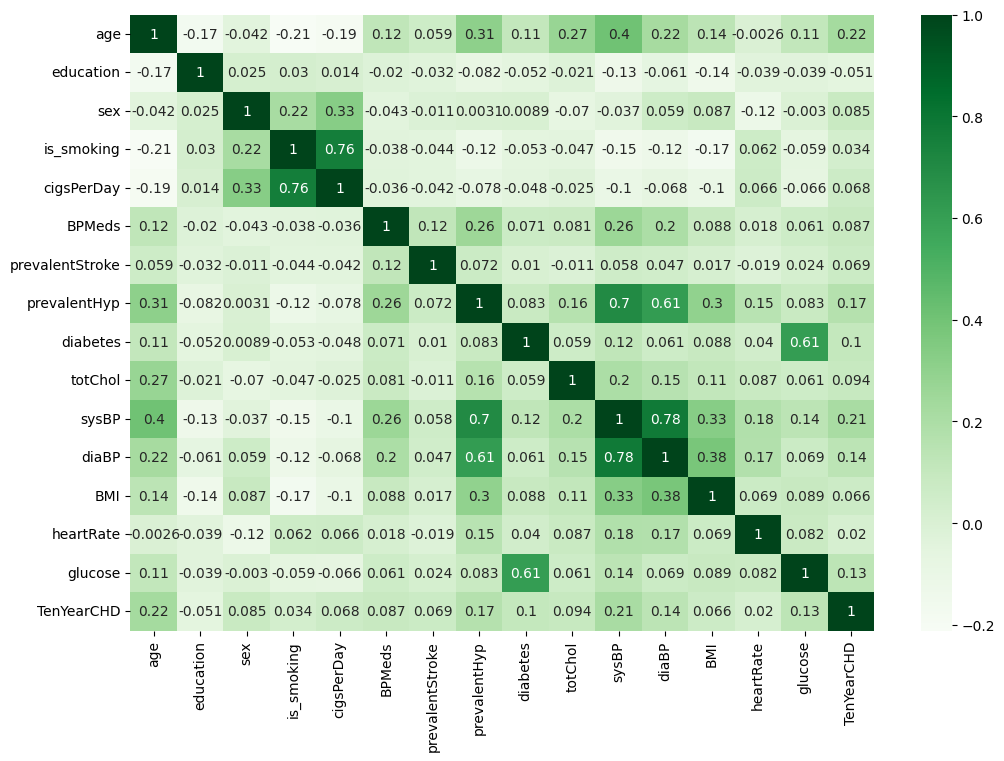

In [178]:
#Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(),annot=True,cmap = 'Greens')

In [179]:
#both the is_smoking and cigsPerDay column give the same information for people who do not smoke
data[data['is_smoking']==0]

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1,36,4.0,1,0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
5,61,3.0,0,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1
6,61,1.0,1,0,0.0,0.0,0,1,0,238.0,232.0,136.0,24.83,75.0,79.0,0
9,55,2.0,0,0,0.0,0.0,0,1,0,326.0,144.0,81.0,25.71,85.0,78.0,0
10,61,1.0,0,0,0.0,0.0,0,1,0,234.0,185.0,121.0,35.22,80.0,78.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3384,61,1.0,0,0,0.0,0.0,0,1,0,217.0,182.0,86.0,26.98,105.0,113.0,0
3385,60,1.0,0,0,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,46,1.0,0,0,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3388,60,1.0,1,0,0.0,0.0,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0


# Feature Engineering

In [180]:
#drop the is_smoking column as it does not add any unique information to the model
data.drop('is_smoking',axis=1,inplace=True)

In [181]:
#create a new feature MAP(Mean Arterial Pressure) using both sysBP and diaBP to resolve multicollinearity
data['MAP'] = round((data['sysBP'] + (2 * data['diaBP']))/3,1)
data.head()

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,MAP
0,64,2.0,0,3.0,0.0,0,0,0,221.0,148.0,85.0,25.38,90.0,80.0,1,106.0
1,36,4.0,1,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,121.3
2,46,1.0,0,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,86.0
3,50,1.0,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,111.3
4,64,1.0,0,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,102.2


In [182]:
#drop sysBP and diaBP columns
data.drop(['sysBP','diaBP'],axis=1,inplace=True)
data.head()

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,BMI,heartRate,glucose,TenYearCHD,MAP
0,64,2.0,0,3.0,0.0,0,0,0,221.0,25.38,90.0,80.0,1,106.0
1,36,4.0,1,0.0,0.0,0,1,0,212.0,29.77,72.0,75.0,0,121.3
2,46,1.0,0,10.0,0.0,0,0,0,250.0,20.35,88.0,94.0,0,86.0
3,50,1.0,1,20.0,0.0,0,1,0,233.0,28.26,68.0,94.0,1,111.3
4,64,1.0,0,30.0,0.0,0,0,0,241.0,26.42,70.0,77.0,0,102.2


<Axes: >

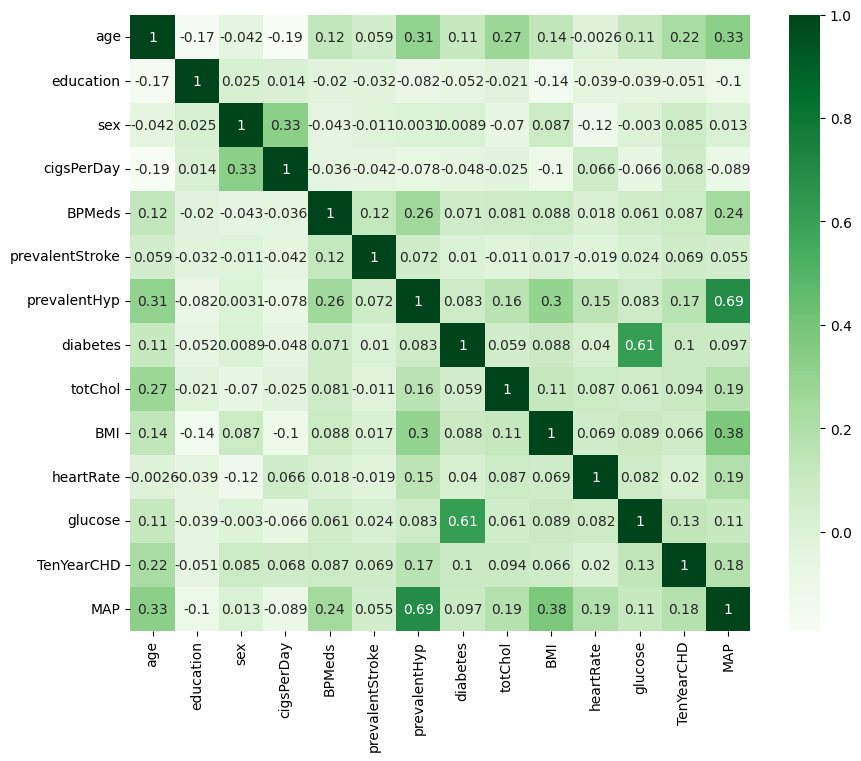

In [183]:
#Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap = 'Greens')

# Model Building

In [184]:
#Train test split 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,f1_score
#Independent and Dependent features
X = data.drop('TenYearCHD',axis=1)
y = data['TenYearCHD']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

#scale the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape,y_train.shape)
print(X_test_scaled.shape,y_test.shape)

(2712, 13) (2712,)
(678, 13) (678,)


In [185]:
y_test.value_counts()

TenYearCHD
0    574
1    104
Name: count, dtype: int64

In [186]:
#model training and selection

models = {'Logistic Regression': LogisticRegression,
         'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_train_scaled,y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_train,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_train,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_train,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_train,y_train_pred)}")
    print(confusion_matrix(y_train,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')


Model-------------------: Logistic Regression


Accuracy score on train set: 0.8591445427728613
Precision score on train set: 0.7358490566037735
Recall score on train set: 0.09582309582309582
F1 score on train set: 0.16956521739130434
[[2291   14]
 [ 368   39]]


Accuracy score on test set: 0.8451327433628318
Precision score on test set: 0.46153846153846156
Recall score on test set: 0.057692307692307696
F1 score on test set: 0.10256410256410256
[[567   7]
 [ 98   6]]


Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2305    0]
 [   0  407]]


Accuracy score on test set: 0.7404129793510325
Precision score on test set: 0.19491525423728814
Recall score on test set: 0.22115384615384615
F1 score on test set: 0.2072072072072072
[[479  95]
 [ 81  23]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train 

# Oversampling using SMOTE

In [187]:
#perform oversampling using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)


In [188]:
X_resampled.shape, y_resampled.shape

((4610, 13), (4610,))

In [189]:
#target class is balanced after applying SMOTE technique
y_resampled.value_counts()

TenYearCHD
0    2305
1    2305
Name: count, dtype: int64

In [190]:
models = {'Logistic Regression': LogisticRegression,
         'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_resampled,y_resampled)
    y_train_pred = model.predict(X_resampled)
    y_test_pred = model.predict(X_test_scaled)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_resampled,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_resampled,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_resampled,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_resampled,y_train_pred)}")
    print(confusion_matrix(y_resampled,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')

Model-------------------: Logistic Regression


Accuracy score on train set: 0.6828633405639913
Precision score on train set: 0.6771752837326608
Recall score on train set: 0.6989154013015184
F1 score on train set: 0.6878736122971819
[[1537  768]
 [ 694 1611]]


Accuracy score on test set: 0.6297935103244838
Precision score on test set: 0.22878228782287824
Recall score on test set: 0.5961538461538461
F1 score on test set: 0.33066666666666666
[[365 209]
 [ 42  62]]


Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2305    0]
 [   0 2305]]


Accuracy score on test set: 0.7079646017699115
Precision score on test set: 0.19480519480519481
Recall score on test set: 0.28846153846153844
F1 score on test set: 0.23255813953488372
[[450 124]
 [ 74  30]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set

# Undersampling

In [191]:
#perform undersampling
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_undersampled, y_undersampled = undersampler.fit_resample(X_train_scaled, y_train)

In [192]:
X_undersampled.shape,y_undersampled.shape

((814, 13), (814,))

In [193]:
y_undersampled.value_counts()

TenYearCHD
0    407
1    407
Name: count, dtype: int64

In [194]:
models = {'Logistic Regression': LogisticRegression,
         'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_undersampled,y_undersampled)
    y_train_pred = model.predict(X_undersampled)
    y_test_pred = model.predict(X_test_scaled)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_undersampled,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_undersampled,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_undersampled,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_undersampled,y_train_pred)}")
    print(confusion_matrix(y_undersampled,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')

Model-------------------: Logistic Regression


Accuracy score on train set: 0.6781326781326781
Precision score on train set: 0.6799007444168734
Recall score on train set: 0.6732186732186732
F1 score on train set: 0.6765432098765433
[[278 129]
 [133 274]]


Accuracy score on test set: 0.6283185840707964
Precision score on test set: 0.22592592592592592
Recall score on test set: 0.5865384615384616
F1 score on test set: 0.32620320855614976
[[365 209]
 [ 43  61]]


Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[407   0]
 [  0 407]]


Accuracy score on test set: 0.5501474926253688
Precision score on test set: 0.17049180327868851
Recall score on test set: 0.5
F1 score on test set: 0.254278728606357
[[321 253]
 [ 52  52]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on trai

We can observe that after applying undersampling all the models perform reasonably better than the base models with Random Forest model performing the best. We can also observe the boosting models performing better than the base boosting models as well as the boosting models where oversampling using SMOTE was used.

# Oversampling using SMOTE TOMEK

In [195]:
#perform combination of undersampling and oversampling
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=42)
X_sampled, y_sampled = smote_tomek.fit_resample(X_train_scaled, y_train)

In [196]:
X_sampled.shape,y_sampled.shape

((4578, 13), (4578,))

In [197]:
y_sampled.value_counts()

TenYearCHD
0    2289
1    2289
Name: count, dtype: int64

In [198]:
models = {'Logistic Regression': LogisticRegression,
         'Decision Tree Classifier': DecisionTreeClassifier,
         'Random Forest Classifier': RandomForestClassifier,
         'Adaboost Classifier': AdaBoostClassifier,
         'Gradient Boosting Classifier': GradientBoostingClassifier,
         'XGBoost Classifier': XGBClassifier}

#training the model
for i in models.keys():
    #Instantiate the model
    model = models[i]()
    model.fit(X_sampled,y_sampled)
    y_train_pred = model.predict(X_sampled)
    y_test_pred = model.predict(X_test_scaled)
    
    print(f'Model-------------------: {i}')
    print('\n')
    #performance on training data
    print(f"Accuracy score on train set: {accuracy_score(y_sampled,y_train_pred)}")
    print(f"Precision score on train set: {precision_score(y_sampled,y_train_pred)}")
    print(f"Recall score on train set: {recall_score(y_sampled,y_train_pred)}")
    print(f"F1 score on train set: {f1_score(y_sampled,y_train_pred)}")
    print(confusion_matrix(y_sampled,y_train_pred))
    print('\n')
    #performance on test data
    print(f"Accuracy score on test set: {accuracy_score(y_test,y_test_pred)}")
    print(f"Precision score on test set: {precision_score(y_test,y_test_pred)}")
    print(f"Recall score on test set: {recall_score(y_test,y_test_pred)}")
    print(f"F1 score on test set: {f1_score(y_test,y_test_pred)}")
    print(confusion_matrix(y_test,y_test_pred))
    print('\n')

Model-------------------: Logistic Regression


Accuracy score on train set: 0.6843599825251201
Precision score on train set: 0.6788135593220339
Recall score on train set: 0.6998689384010485
F1 score on train set: 0.6891804689180469
[[1531  758]
 [ 687 1602]]


Accuracy score on test set: 0.6327433628318584
Precision score on test set: 0.23048327137546468
Recall score on test set: 0.5961538461538461
F1 score on test set: 0.3324396782841823
[[367 207]
 [ 42  62]]


Model-------------------: Decision Tree Classifier


Accuracy score on train set: 1.0
Precision score on train set: 1.0
Recall score on train set: 1.0
F1 score on train set: 1.0
[[2289    0]
 [   0 2289]]


Accuracy score on test set: 0.700589970501475
Precision score on test set: 0.17647058823529413
Recall score on test set: 0.25961538461538464
F1 score on test set: 0.21011673151750973
[[448 126]
 [ 77  27]]


Model-------------------: Random Forest Classifier


Accuracy score on train set: 1.0
Precision score on train set: 

After using both the oversampling and undersampling techniques such as SMOTE, Undersampling and SMOTE TOMEK, we found the Random Forest model using SMOTE TOMEK to be the best performing with 71/104 instances of the minority class predicted correctly on the test data. Hence, we will apply hyperparameter tuning on this model to further reduce the amount of false negatives, which in turn will improve the recall score of the minority class.

# Hyperparameter Tuning 

In [206]:
#hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# Define the parameter grid to sample from during the search
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None] + list(range(10, 51, 10)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# Initialize the classifier
rf = RandomForestClassifier(random_state=42)

# Initialize Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the RandomizedSearchCV with scoring set to recall_macro to reduce false negatives
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=100, cv=skf, n_jobs=-1, verbose=1, random_state=42,
                                   scoring='recall')

# Fit the RandomizedSearchCV to the data
random_search.fit(X_undersampled, y_undersampled)

# Get the best parameters
best_params = random_search.best_params_
print(f"Best parameters found: {best_params}")

# Get the best model
best_model = random_search.best_estimator_

# Predict with the best model using the test set
y_pred = best_model.predict(X_test_scaled)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Recall: {recall_score(y_test,y_pred)}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found: {'criterion': 'gini', 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 77}
              precision    recall  f1-score   support

           0       0.91      0.61      0.73       574
           1       0.23      0.65      0.34       104

    accuracy                           0.62       678
   macro avg       0.57      0.63      0.54       678
weighted avg       0.80      0.62      0.67       678

[[351 223]
 [ 36  68]]
Recall: 0.6538461538461539


# Feature Importances

In [207]:
#feature importances
data = {'Features': X.columns, 'Importance': best_model.feature_importances_}
feature_df = pd.DataFrame(data)
feature_df

,Features,Importance
0,age,0.191508
1,education,0.031824
2,sex,0.027345
3,cigsPerDay,0.057602
4,BPMeds,0.003596
5,prevalentStroke,0.000529
6,prevalentHyp,0.052755
7,diabetes,0.006853
8,totChol,0.117961
9,BMI,0.115790


<Axes: xlabel='Importance', ylabel='Features'>

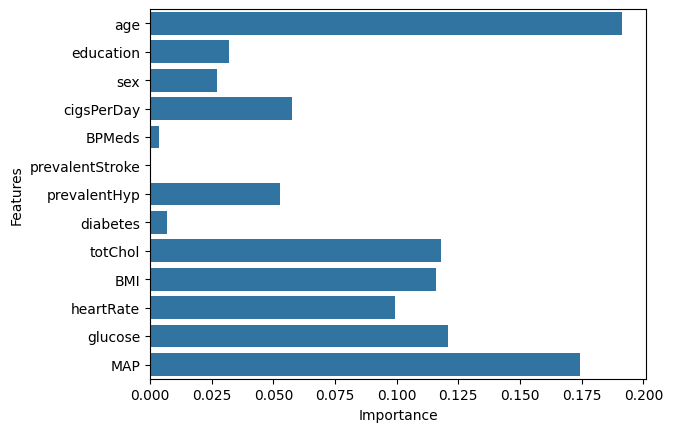

In [208]:
#plot feature importances
sns.barplot(x = feature_df['Importance'], y = feature_df['Features'])

<Axes: >

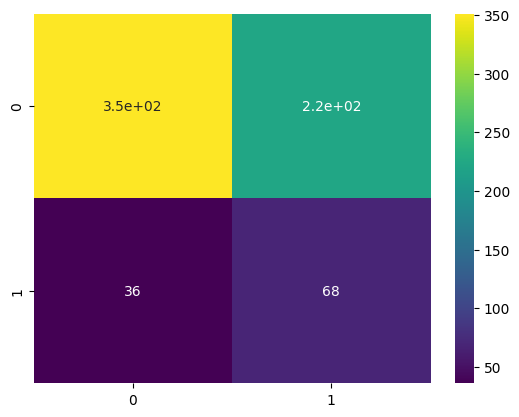

In [209]:
#final confusion matrix
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,cmap='viridis')

In [210]:
import joblib

# Save the model as a .pkl file
joblib.dump(best_model, 'random_forest_best_model.pkl')


['random_forest_best_model.pkl']

In [211]:
#save scaler as pickle file
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [212]:
X_test.head()

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,BMI,heartRate,glucose,MAP
1296,64,4.0,0,9.0,0.0,0,0,0,342.0,20.52,60.0,62.0,90.0
663,61,4.0,1,10.0,0.0,0,0,0,258.0,24.35,67.0,78.0,90.0
648,58,1.0,1,0.0,0.0,0,1,0,333.0,28.38,75.0,78.0,110.3
2715,46,1.0,1,0.0,0.0,0,1,0,235.0,22.92,68.0,89.0,106.8
1678,65,1.0,0,0.0,0.0,0,1,0,245.0,23.07,82.0,93.0,116.3
